In [1]:
# Step 1: Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, recall_score, precision_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')

print(' All libraries imported!')

 All libraries imported!


In [2]:
# Step 2: Loading Dataset

DATA_FILE      = r'C:\Nepal_Flood_Project\Data\final_landslide_dataset_ml_ready.csv'
FULL_DATA_FILE = r'C:\Nepal_Flood_Project\Data\final_landslide_dataset.csv'

df = pd.read_csv(DATA_FILE)

print(f' Dataset loaded!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nLabel distribution:')
print(df['landslide_risk_label'].value_counts().rename({0:"Low", 1:"Medium", 2:"High"}))

 Dataset loaded!
Shape: 66479 rows × 12 columns

Columns: ['temperature', 'rainfall', 'humidity', 'wind_speed', 'rain_3day', 'rain_7day', 'soil_moisture', 'slope', 'month', 'season_encoded', 'location_encoded', 'landslide_risk_label']

Label distribution:
landslide_risk_label
Low       65335
High        744
Medium      400
Name: count, dtype: int64


In [3]:
# Step 3: Separating Features and Label

X = df.drop(columns=['landslide_risk_label'])
y = df['landslide_risk_label']

print(f' Features and label separated!')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nFeature columns: {X.columns.tolist()}')
print(f'\nUnique labels: {sorted(y.unique())}')

 Features and label separated!
X shape: (66479, 11)
y shape: (66479,)

Feature columns: ['temperature', 'rainfall', 'humidity', 'wind_speed', 'rain_3day', 'rain_7day', 'soil_moisture', 'slope', 'month', 'season_encoded', 'location_encoded']

Unique labels: [np.int64(0), np.int64(1), np.int64(2)]


In [4]:
# Step 4: Temporal Train/Test Split

from sklearn.model_selection import train_test_split
FULL_DATA_FILE = r'C:\Nepal_Flood_Project\Data\final_landslide_dataset.csv'
df_full = pd.read_csv(FULL_DATA_FILE)
df_full['date'] = pd.to_datetime(df_full['date'])
feature_cols = [
    'temperature', 'rainfall', 'humidity',
    'wind_speed', 'rain_3day', 'rain_7day',
    'soil_moisture', 'slope', 'month',
    'season_encoded', 'location_encoded'
]

train_data = df_full[df_full['date'].dt.year <= 2020]
test_data  = df_full[df_full['date'].dt.year >= 2021]

X_train = train_data[feature_cols]
y_train = train_data['landslide_risk_label']
X_test  = test_data[feature_cols]
y_test  = test_data['landslide_risk_label']

print(' Temporal split complete!')
print(f'Training: 2000–2020 → {len(X_train)} rows')
print(f'Testing:  2021–2025 → {len(X_test)} rows')
print(f'\nTraining label distribution:')
print(y_train.value_counts().rename({0:"Low", 1:"Medium", 2:"High"}))
print(f'\nTesting label distribution:')
print(y_test.value_counts().rename({0:"Low", 1:"Medium", 2:"High"}))

 Temporal split complete!
Training: 2000–2020 → 53697 rows
Testing:  2021–2025 → 12782 rows

Training label distribution:
landslide_risk_label
Low       52829
High        578
Medium      290
Name: count, dtype: int64

Testing label distribution:
landslide_risk_label
Low       12506
High        166
Medium      110
Name: count, dtype: int64


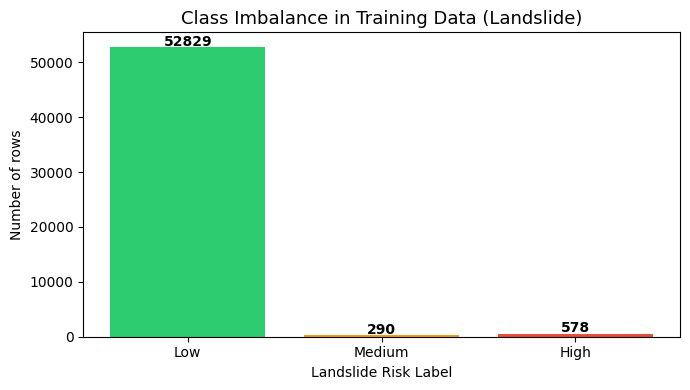

 Class imbalance visualized!


In [5]:
# Step 5: Visualizing Class Imbalance

label_names = {0: 'Low', 1: 'Medium', 2: 'High'}
counts = y_train.value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

plt.figure(figsize=(7, 4))
plt.bar([label_names[i] for i in counts.index], counts.values, color=colors)
plt.title('Class Imbalance in Training Data (Landslide)', fontsize=13)
plt.ylabel('Number of rows')
plt.xlabel('Landslide Risk Label')
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('landslide_class_imbalance.png', dpi=150)
plt.show()
print(' Class imbalance visualized!')

In [6]:
# Step 6: Training Random Forest Model

print(' Training Random Forest model...')

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f'\n Random Forest training complete!')
print(f'Accuracy on test data: {rf_accuracy*100:.2f}%')

 Training Random Forest model...

 Random Forest training complete!
Accuracy on test data: 95.46%


In [7]:
# Step 7: Training XGBoost Model

print(' Training XGBoost model...')

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=3,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print(f'\n XGBoost training complete!')
print(f'Accuracy on test data: {xgb_accuracy*100:.2f}%')

 Training XGBoost model...

 XGBoost training complete!
Accuracy on test data: 97.82%


In [8]:
# Step 8: Evaluating Both Models

label_names = ['Low', 'Medium', 'High']

print('=' * 60)
print(' RANDOM FOREST - Detailed Evaluation')
print('=' * 60)
print(classification_report(y_test, rf_predictions, target_names=label_names))

print('=' * 60)
print(' XGBOOST - Detailed Evaluation')
print('=' * 60)
print(classification_report(y_test, xgb_predictions, target_names=label_names))

 RANDOM FOREST - Detailed Evaluation
              precision    recall  f1-score   support

         Low       0.98      0.97      0.98     12506
      Medium       0.20      0.38      0.26       110
        High       0.08      0.10      0.09       166

    accuracy                           0.95     12782
   macro avg       0.42      0.49      0.44     12782
weighted avg       0.96      0.95      0.96     12782

 XGBOOST - Detailed Evaluation
              precision    recall  f1-score   support

         Low       0.98      1.00      0.99     12506
      Medium       0.00      0.00      0.00       110
        High       0.17      0.01      0.01       166

    accuracy                           0.98     12782
   macro avg       0.38      0.34      0.33     12782
weighted avg       0.96      0.98      0.97     12782



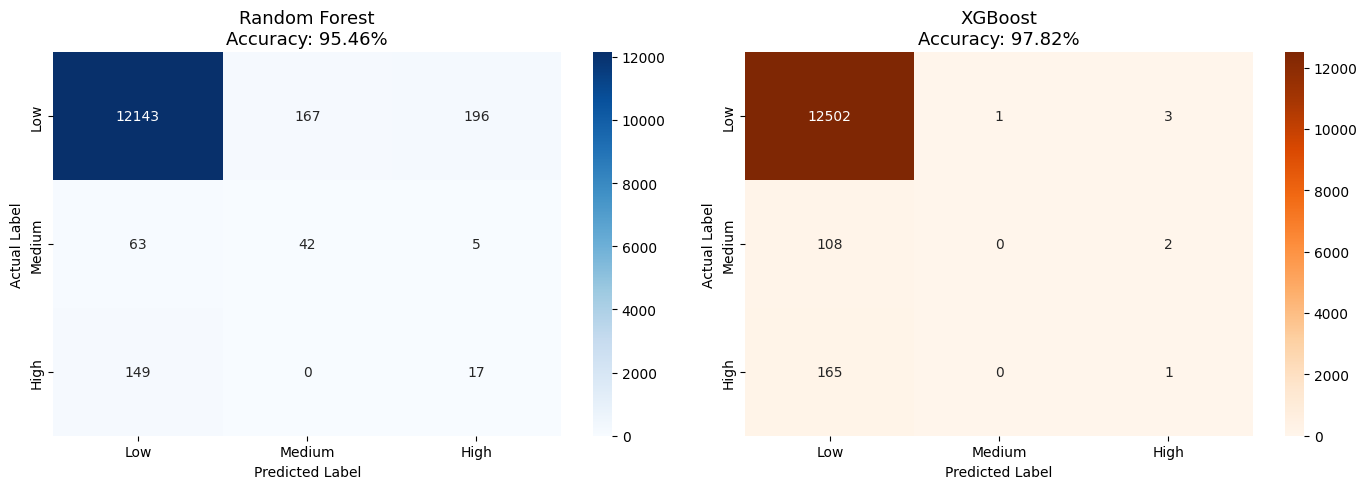

 Confusion matrices saved!


In [9]:
# Step 9: Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title(f'Random Forest\nAccuracy: {rf_accuracy*100:.2f}%', fontsize=13)
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

xgb_cm = confusion_matrix(y_test, xgb_predictions)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title(f'XGBoost\nAccuracy: {xgb_accuracy*100:.2f}%', fontsize=13)
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('landslide_confusion_matrices.png', dpi=150)
plt.show()
print(' Confusion matrices saved!')

In [10]:
# Step 10: Comparing Both Models

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Overall Accuracy': [
        round(rf_accuracy * 100, 2),
        round(xgb_accuracy * 100, 2)
    ],
    'High Risk Recall (%)': [
        round(recall_score(y_test, rf_predictions, average=None, zero_division=0)[2] * 100, 2),
        round(recall_score(y_test, xgb_predictions, average=None, zero_division=0)[2] * 100, 2)
    ],
    'High Risk Precision (%)': [
        round(precision_score(y_test, rf_predictions, average=None, zero_division=0)[2] * 100, 2),
        round(precision_score(y_test, xgb_predictions, average=None, zero_division=0)[2] * 100, 2)
    ],
    'Macro F1 Score': [
        round(f1_score(y_test, rf_predictions, average='macro') * 100, 2),
        round(f1_score(y_test, xgb_predictions, average='macro') * 100, 2)
    ]
})

print('=' * 65)
print(' MODEL COMPARISON RESULTS')
print('=' * 65)
print(results.to_string(index=False))
print('=' * 65)

best_idx = results['High Risk Recall (%)'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
print(f'\n Best model based on High Risk Recall: {best_model_name}')

 MODEL COMPARISON RESULTS
        Model  Overall Accuracy  High Risk Recall (%)  High Risk Precision (%)  Macro F1 Score
Random Forest             95.46                 10.24                     7.80           44.29
      XGBoost             97.82                  0.60                    16.67           33.36

 Best model based on High Risk Recall: Random Forest


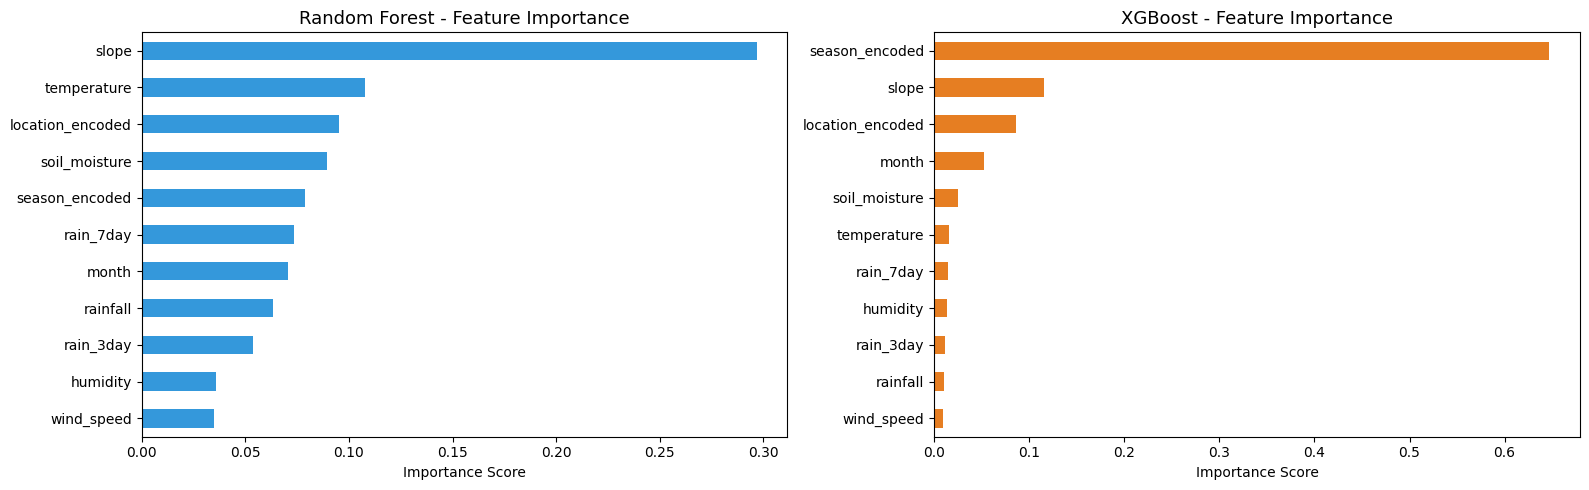

 Feature importance saved!


In [11]:
# Step 11: Feature Importance

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols)
rf_importance.sort_values().plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Random Forest - Feature Importance', fontsize=13)
axes[0].set_xlabel('Importance Score')

xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols)
xgb_importance.sort_values().plot(kind='barh', ax=axes[1], color='#e67e22')
axes[1].set_title('XGBoost - Feature Importance', fontsize=13)
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('landslide_feature_importance.png', dpi=150)
plt.show()
print(' Feature importance saved!')

In [12]:
# Step 12: Saving Both Models

joblib.dump(rf_model,  'landslide_random_forest_model.pkl')
joblib.dump(xgb_model, 'landslide_xgboost_model.pkl')

print(' Models saved!')
print('   landslide_random_forest_model.pkl')
print('   landslide_xgboost_model.pkl')

 Models saved!
   landslide_random_forest_model.pkl
   landslide_xgboost_model.pkl


In [13]:
# Step 13: Test with Sample Predictions - Updated

label_map = {0: '🟢 Low Risk', 1: '🟡 Medium Risk', 2: '🔴 High Risk'}

# [temp, rainfall, humidity, wind, rain_3day, rain_7day,
#  soil_moisture, slope, month, season_encoded, location_encoded]

test_scenarios = [
    # Scenario 1: Dry winter day Biratnagar (Terai — always Low)
    [17.0, 0.0, 32.0, 1.0, 0.0, 0.0, 0.40, 0.73, 1, 3, 0],

    # Scenario 2: Monsoon day Kathmandu moderate rain
    [22.0, 30.0, 88.0, 2.5, 70.0, 150.0, 0.80, 1.67, 7, 0, 3],

    # Scenario 3: Extreme monsoon day Illam
    # Very heavy rain, saturated soil, steep slope
    [23.0, 150.0, 99.0, 5.0, 350.0, 600.0, 0.99, 14.16, 8, 0, 1],

    # Scenario 4: Extreme monsoon day Manang
    # Very heavy rain, saturated soil, steepest slope
    [15.0, 120.0, 98.0, 4.5, 280.0, 500.0, 0.99, 15.46, 7, 0, 4],
]

scenario_names = [
    'Dry Winter Day (Biratnagar — Terai)',
    'Monsoon Day (Kathmandu)',
    'Extreme Monsoon Day (Illam — 14° slope)',
    'Extreme Monsoon Day (Manang — 15° slope)',
]

print('🧪 Testing model with sample scenarios:')
print('=' * 65)

for name, values in zip(scenario_names, test_scenarios):
    input_data = pd.DataFrame([values], columns=feature_cols)
    rf_pred  = rf_model.predict(input_data)[0]
    xgb_pred = xgb_model.predict(input_data)[0]
    print(f'\nScenario: {name}')
    print(f'  Random Forest → {label_map[rf_pred]}')
    print(f'  XGBoost       → {label_map[xgb_pred]}')

print('\n' + '=' * 65)
print('✅ Sample predictions complete!')
print('\n🎉 LANDSLIDE MODEL TRAINING COMPLETE!')

🧪 Testing model with sample scenarios:

Scenario: Dry Winter Day (Biratnagar — Terai)
  Random Forest → 🟢 Low Risk
  XGBoost       → 🟢 Low Risk

Scenario: Monsoon Day (Kathmandu)
  Random Forest → 🟢 Low Risk
  XGBoost       → 🟢 Low Risk

Scenario: Extreme Monsoon Day (Illam — 14° slope)
  Random Forest → 🟢 Low Risk
  XGBoost       → 🟢 Low Risk

Scenario: Extreme Monsoon Day (Manang — 15° slope)
  Random Forest → 🟢 Low Risk
  XGBoost       → 🟢 Low Risk

✅ Sample predictions complete!

🎉 LANDSLIDE MODEL TRAINING COMPLETE!
